# Models trained on unmatched original cohort. 

In [1]:
import sys
print(f"Python version: {sys.version}")
import json
import logging
import csv
import gzip
import re
import pandas as pd
import numpy as np
from functools import reduce
from pyspark.sql.types import StringType,DecimalType,DoubleType,IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.feature import VectorAssembler, Bucketizer
import matplotlib.pyplot as plt
import pyspark.sql.functions as F
import pyspark.sql.types as T
from pyspark.sql import SparkSession,Row
from pyspark import SparkConf
import plotly.express as px
import plotly.graph_objects as go
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# -----------------------------------------------------------------------------
# INITIALIZE LOGGING
# -----------------------------------------------------------------------------
f = '%(asctime)-15s %(levelname)-8s %(message)s'
logger = logging.getLogger(__name__)
logger.setLevel("DEBUG")
logging.basicConfig(format=f)


from IPython.core.magic import register_cell_magic

# -----------------------------------------------------------------------------
# start_spark
# -----------------------------------------------------------------------------
def start_spark(
    driver_memory="100g",
    storage_fraction=0.5,
    num_nodes=10,
):
    """Initialize spark

    Arguments:
        driver_memory: Maximum heap size for the Spark driver Java
            virtual machine.
        storage_fraction: Controls what portion of Spark's unified
            memory is reserved for storage (i.e., caching/persisting data
            and broadcast variables), as a fraction of the total
            execution + storage memory pool.
            If you cache/persist a lot of data, and you're evicting
            data too early, you might increase this value (e.g. 0.6 or 0.7).
            Conversely, if your job is shuffle-heavy and fails due to
            memory pressure, you might decrease it (e.g. 0.3).
        num_nodes: How many concurrent threads to use while running
            in "local mode" (i.e. in a single machine instead of a cluster).
            Use '*' to use all cores, or an integer > 0 for a specific
            number of threads.
    """

    conf = SparkConf().setAppName("My_Application")
    conf.set("spark.driver.memory", driver_memory)
    conf.set("spark.memory.storageFraction", str(storage_fraction))
    conf.setMaster(f"local[{num_nodes}]")

    spark = SparkSession.builder.config(conf=conf).getOrCreate()
    spark.sparkContext.setLogLevel('WARN')

    return spark


Python version: 3.11.0 (main, Jun 13 2025, 14:48:45) [Clang 16.0.0 (clang-1600.0.26.6)]


In [2]:

spark = start_spark(num_nodes=10)
#spark.stop()

  
@register_cell_magic
def spark_sql(line, cell):
    result = spark.sql(cell)
    result.show(n=1000)
  

# -- READ ENROLLMENT AND DATA TABLES
enrollment_file = f"/Users/Charles/DATA/ckd/ckd_enrollment"
logger.info(f">>> Reading enrollment file: {enrollment_file}")
df_enrollment = spark.read.format("parquet").load(enrollment_file)
df_enrollment.createOrReplaceTempView('enrollment')
logger.info(f">>> ENROLLMENT has {df_enrollment.count():,} rows")
logger.info(f">>> ENROLLMENT has {df_enrollment.select('ENROLID').distinct().count():,} unique enrollees")

claims_file = f"/Users/Charles/DATA/ckd/ckd_claims"
logger.info(f">>> Reading claims file: {claims_file}")
df_claims = spark.read.format("parquet").load(claims_file)
df_claims.createOrReplaceTempView('claims')
logger.info(f">>> CLAIMS has {df_claims.count():,} rows")
logger.info(f">>> CLAIMS has {df_claims.select('ENROLID').distinct().count():,} unique enrollees")

# -- NOTE: with the "createOrReplaceTempView" we define a view of these
# -- tables, so we can use them in SQL queries.

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/09/11 18:33:05 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/09/11 18:33:05 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
2025-09-11 18:33:06,993 INFO     >>> Reading enrollment file: /Users/Charles/DATA/ckd/ckd_enrollment
25/09/11 18:33:08 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
2025-09-11 18:33:09,036 INFO     >>> ENROLLMENT has 2,586,930 rows
2025-09-11 18:33:11,345 INFO     >>> ENROLLMENT has 862,310 unique enrollees    
2025-09-11 18:33:11,346 INFO     >>> Reading claims file: /Users/Charles/DATA/ckd/ckd_claims
2025-09-11 18:33

# Load Data

In [3]:
############### creating 0831_2017_18_highcost_cutoffs.parquet
from pyspark.sql.functions import concat_ws, col
df_2018_init =spark.read.format("parquet").load( "0813_adherence_features_2017.parquet")
#df_2018_init =spark.read.format("parquet").load( "0813_cost_with_derivatives_2017.parquet")
df_2018 = spark.read.format("parquet").load( "df_0827_2017_18_highcost_cutoffs.parquet")
df_merged = (df_2018    
        .join(df_2018_init, on="ENROLID", how="inner")   # inner keeps only pilot IDs
)
df_2018_final = (df_merged.filter(df_merged["annual_cost17"] > -1)
.filter(df_merged["annual_cost17"].isNotNull())
.drop("YEAR","cost_stratum_2018",'first_nephrology_date','first_ckd_date',
 'total_ckd_cost_2017', '2017Q1',
 '2017Q2',
 '2017Q3',
 '2017Q4',
 'cost_stratum_2017',
))


In [4]:
df_2018 = spark.read.format("parquet").load( "0902_adherence_income_info.parquet")
df_og = df_2018.toPandas()
#df_og["INDSTRY"]= df_og["INDSTRY"].fillna("0")
#df_og.drop(columns = [ 'first_ckd_date', 'ckd_visit_count', 'quarters_with_labs',
# 'nephrology_visit_count', 'days_to_nephrology','first_nephrology_date',],inplace=True)
df_og.shape,df_og.columns
sum(df_og.annual_cost17<0)

0

In [5]:
highcost_cutoff = 4
stratifier_cutoff = 3
import importlib
import model_pipeline
importlib.reload(model_pipeline)

# Correctly import your custom modules
import evaluate_model_by_cost_stratum
import evaluate_model_by_risk_bin

# Then reload them
importlib.reload(evaluate_model_by_risk_bin)
importlib.reload(evaluate_model_by_cost_stratum)
# Import with correct syntax
import model_IAI
from model_IAI import train_oct_with_feature_names,train_opt_with_feature_names
importlib.reload(model_IAI)
from evaluate_model_by_risk_bin import evaluate_metrics_by_risk_bin, plot_probability_and_calibration

df_og.ENROLID.nunique()


33551

# Feature groups, define high cost and train-test-split

In [6]:
BIN_FLAG_COLUMNS = model_pipeline.get_bin_flag_columns(df_og) +['lab_monitoring_adherent','nephrology_consult_adherent','early_nephrology_referral']
STAGE_COLUMNS = ['2017Q1', '2017Q2', '2017Q3', '2017Q4',"stage_2017",'2017Q1_max_ckd_stage','2017Q2_max_ckd_stage', '2017Q3_max_ckd_stage','2017Q4_max_ckd_stage', ]
CAT_COLUMNS = df_og.select_dtypes(include=["object","category"]).columns.tolist()
TRUE_NUM_COLUMNS = model_pipeline.get_true_num_columns(df_og,CAT_COLUMNS)+[ 'util_2017', 'total_increasing_quarters_2017'
, 'total_lab_tests', 'ckd_visit_count', 'quarters_with_labs', 'nephrology_visit_count', 'days_to_nephrology','MEDIAN_INCOME']
print("categorical cols: ", CAT_COLUMNS)

leftover_cols = [
    c for c in df_og.columns 
    if c not in CAT_COLUMNS and c not in TRUE_NUM_COLUMNS and c not in STAGE_COLUMNS and c not in BIN_FLAG_COLUMNS 
]

print(f"Number of leftover columns: {len(leftover_cols)}")
print(leftover_cols, df_og.shape)  # preview first 50

categorical cols:  ['ENROLID', 'INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
Number of leftover columns: 0
[] (33551, 87)


In [7]:
df_og["high_cost_2018"] = df_og["highcost_gt_75000"] 
#df_og = df_og[df_og["high_cost_2018"].notna()]
df_og["high_cost_2018"].value_counts(dropna=False)

high_cost_2018
0    30527
1     3024
Name: count, dtype: int64

In [8]:
cutoff_columns = [col for col in df_og.columns if col.startswith('highcost_gt_')]

feature_cols = [c for c in df_og.columns
              if c not in  (["ENROLID", "high_cost_2018"] + cutoff_columns)]    # keep only predictors
numeric_cols = df_og[feature_cols + ["high_cost_2018"]].select_dtypes(include=["number"]).columns
corrs = df_og[numeric_cols].corr()["high_cost_2018"].abs().sort_values(ascending=False)
# Columns to drop
high_corr_cols = corrs[corrs > 0.5].index.tolist()
# Remove the target column itself, if present
high_corr_cols = [col for col in high_corr_cols if col != "high_cost_2018"]
# Final filtered feature set
feature_cols = [col for col in feature_cols if col not in high_corr_cols]
print("High corr features dropped from prediction columns: ",high_corr_cols)
# 2) split
train_ids, test_ids,train_pd,test_pd = model_pipeline.train_test_split_enrol(df_og,target_col = "high_cost_2018",test_size=0.3,verbose=False)

print(train_pd.shape,test_pd.shape)
#baseline_results = evaluate_model_by_cost_stratum.analyze_predictions_by_cost_strata(baselinemodel,test_pd[feature_cols],
#test_pd["cost_stratum_2018"], highcost_cutoff=highcost_cutoff,optimal_threshold=True)


High corr features dropped from prediction columns:  ['annual_cost17']
(23485, 88) (10066, 88)


# Stratification with multi-class classifiers

In [9]:
# ordinal logistic models 

from mord import LogisticAT, LogisticIT, LogisticSE
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score
from scipy.stats import kendalltau, spearmanr
import numpy as np
import pandas as pd
# Create multi-class target from annual_cost17
def create_cost_strata(df, cost_column, n_strata, method='quantile'):
    """
    Create multi-class cost strata
    
    Parameters:
    - method: 'quantile' for equal-sized bins, 'percentile' for predefined cutoffs
    """
    if method == 'quantile':
        # Equal-sized quantile bins
        df['cost_stratum'] = pd.qcut(
            df[cost_column], 
            q=n_strata, 
            labels=[f"Stratum_{i}" for i in range(n_strata)],
            duplicates='drop'  # Handle ties
        )
    elif method == 'percentile':
        # Custom percentile-based bins (e.g., focus on high-cost tail)
        percentiles = [0, 50, 70, 80, 90, 95, 98, 100][:n_strata+1]
        bin_edges = np.percentile(df[cost_column], percentiles)
        df['cost_stratum'] = pd.cut(
            df[cost_column],
            bins=bin_edges,
            labels=[f"Stratum_{i}" for i in range(len(bin_edges)-1)],
            include_lowest=True
        )
    
    return df

# Modified stratification training using OCT multi-class classification
n_strata = 8  # Number of cost strata
stratifier_stage_cutoff = 3
stratifier_target_column = "annual_cost17"
stratification_method='quantile'
# Train stratifier on configurable stage cutoff
stratifier_train_pd = df_og[df_og["stage_2017"] > stratifier_stage_cutoff].copy()
logger.info(f"Stratifier trained on subgroup of size {len(stratifier_train_pd)}")

# Create multi-class cost strata for training data
stratifier_train_pd = create_cost_strata(
    stratifier_train_pd, 
    stratifier_target_column, 
    n_strata= n_strata,  # or 8, 9, 10 as desired,
    method=stratification_method
)

2025-09-11 15:14:13,797 INFO     Stratifier trained on subgroup of size 4985


In [10]:
# Remove stage columns from stratification features
stratification_cols = [c for c in feature_cols if c not in STAGE_COLUMNS]
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Prepare features and target
X_train = stratifier_train_pd[stratification_cols]
y_train = stratifier_train_pd['cost_stratum']
# Encode ordinal labels as integers
le = LabelEncoder()
y_train_ordinal = le.fit_transform(y_train)

# 2. Create and fit preprocessor
preprocessor = model_pipeline.get_preprocessor(
    df=X_train,
    categorical_cols=CAT_COLUMNS, 
    numeric_cols=TRUE_NUM_COLUMNS,
    verbose=True
)

# Fit preprocessor and transform training data
X_train_processed = preprocessor.fit_transform(X_train)
print(f"Training data shape after preprocessing: {X_train_processed.shape}")

# 3. Train ordinal logistic regression models
ordinal_models = {
    'LogisticAT': LogisticAT(alpha=1.0), #
    'LogisticIT': LogisticIT(alpha=1.0), # (Immediate-Threshold variant)
    'LogisticSE': LogisticSE(alpha=1.0) 
}

trained_models = {}
for name, model in ordinal_models.items():
    print(f"Training {name}...")
    model.fit(X_train_processed, y_train_ordinal)
    trained_models[name] = model
    print(f"{name} trained successfully")

→ Building preprocessor:
   • OneHotEncoder on: ['INCOME_LEVEL', 'AGEGRP', 'SEX', 'REGION', 'cost_pattern_2017', 'cost_stability_2017', 'lab_monitoring_intensity']
   • StandardScaler on: ['2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'ckd_cost_deriv_Q1_Q2_2017', 'ckd_cost_deriv_Q2_Q3_2017', 'ckd_cost_deriv_Q3_Q4_2017', 'avg_quarterly_derivative_2017', 'quarterly_std_2017', 'quarterly_skewness_2017', 'quarterly_kurtosis_2017', 'quarterly_cv_2017', 'quarterly_max_2017', 'quarterly_min_20

In [11]:
best_model = ordinal_models.get("LogisticAT")

In [12]:
# Apply ordinal logistic regression to full dataset
df_binned = df_og.copy()

# Preprocess the full dataset using the fitted preprocessor
X_full_processed = preprocessor.transform(df_binned[stratification_cols])

# Get predicted strata from the best ordinal model
predicted_strata_ordinal = best_model.predict(X_full_processed)

# Convert back to stratum labels
predicted_strata_labels = le.inverse_transform(predicted_strata_ordinal)
df_binned["risk_bin"] = predicted_strata_labels

# Create true class (Stage ≤3 vs >3) with proper labels
df_binned["true_class"] = (df_binned["stage_2017"] > 3).astype(int)
df_binned["stage_group"] = df_binned["true_class"].map({0: "Stage ≤3", 1: "Stage >3"})

# Get ordered bins (Stratum_0, Stratum_1, ..., Stratum_6)
bins = sorted(df_binned['risk_bin'].unique(), key=lambda x: int(x.split('_')[1]))

# Create the plot
fig = px.histogram(
    df_binned,
    x="risk_bin",
    color="stage_group",  # Use the mapped column instead
    labels={
        "risk_bin": "Predicted Cost Stratum (Ordinal Logistic Regression)",
        "stage_group": "CKD Stage Group",
        "count": "Number of Patients"
    },
    title="Predicted Cost Strata Distribution by CKD Stage Group",
    barmode="group",
    height=500, 
    width=800,
    color_discrete_map={"Stage ≤3": "lightblue", "Stage >3": "coral"}
)

fig.update_xaxes(
    categoryorder="array",
    categoryarray=bins,
    tickangle=-45
)

# Update legend title only
fig.update_layout(
    legend=dict(
        title="CKD Stage Group"
    )
)

fig.show()

# Print distribution summary
print("=== Predicted Strata Distribution ===")
strata_summary = df_binned.groupby(['risk_bin', 'stage_group']).size().unstack(fill_value=0)
strata_summary['Total'] = strata_summary.sum(axis=1)
strata_summary['% Stage >3'] = (strata_summary['Stage >3'] / strata_summary['Total'] * 100).round(1)

print(strata_summary)

=== Predicted Strata Distribution ===
stage_group  Stage >3  Stage ≤3  Total  % Stage >3
risk_bin                                          
Stratum_0          66      1437   1503         4.4
Stratum_1         594      8324   8918         6.7
Stratum_2         871      7702   8573        10.2
Stratum_3        1075      5552   6627        16.2
Stratum_4        1007      3238   4245        23.7
Stratum_5         710      1538   2248        31.6
Stratum_6         383       567    950        40.3
Stratum_7         279       208    487        57.3


In [14]:
train_df = df_binned[df_binned["ENROLID"].isin(train_ids)].reset_index(drop=True)
test_df  = df_binned[df_binned["ENROLID"].isin(test_ids)].reset_index(drop=True)
X_train, y_train = train_df[feature_cols], train_df["high_cost_2018"]
X_test,y_test = test_df[feature_cols], test_df['high_cost_2018']
train_df.to_csv("train_df_logisticAT_0911.csv",index=False)
test_df.to_csv("test_df_logisticAT_0911.csv",index=False)

# Train non-IAI models

In [11]:
negatives = df_og[df_og["annual_cost17"] <= -1]
print(f"Found {len(negatives)} records with cost <= -1:")
display(negatives)
df_og["annual_cost17"] = df_og["annual_cost17"].clip(lower=0)

Found 0 records with cost <= -1:


,ENROLID,INCOME_LEVEL,annual_cost17,highcost_gt_50000,highcost_gt_75000,highcost_gt_100000,highcost_gt_200000,highcost_gt_300000,highcost_gt_400000,highcost_gt_500000,...,quarterly_range_2017,cost_pattern_2017,cost_stability_2017,total_lab_tests,lab_monitoring_adherent,lab_monitoring_intensity,nephrology_visit_count,nephrology_consult_adherent,early_nephrology_referral,high_cost_2018


In [35]:
 
stratifier_stage_cutoff = 3
stratifier_target_column = "annual_cost17"
# Train stratifier on configurable stage cutoff
stratifier_train_pd = df_og[df_og["stage_2017"] > stratifier_stage_cutoff].copy()
#stratifier_train_pd = df_og[df_og["stage_2017"] <= stratifier_stage_cutoff].copy()
logger.info(f"Stratifier trained on subgroup of size {len(stratifier_train_pd)}")

# Remove stage columns from stratification features
stratification_cols = [c for c in feature_cols if c not in STAGE_COLUMNS]

# Use annual_cost17 as stratifier target (not the current cutoff)
if stratifier_target_column not in df_og.columns:
    raise ValueError(f"Stratifier target column '{stratifier_target_column}' not found in data")

# Train stratifier
stratifier, risk_converter = model_pipeline.get_stratifier_model(
    df=stratifier_train_pd[stratification_cols],
    categorical_cols=CAT_COLUMNS, 
    numeric_cols=TRUE_NUM_COLUMNS,
    model_type="regression"  # or 'binary'
    )
stratifier.fit(stratifier_train_pd[stratification_cols], stratifier_train_pd[stratifier_target_column])

# Apply to full cohort
X_full = df_og[stratification_cols]
predictions = stratifier.predict(X_full)
training_predictions = stratifier.predict(stratifier_train_pd[stratification_cols])  # For ECDF reference

risk_scores = risk_converter(predictions, training_predictions)
df_binned = df_og.copy()
df_binned["risk_score"] = risk_scores
logger.info(f"Inference on full cohort of size: {len(risk_scores)}")

# Create risk bins using fixed probability bins
bin_edges = np.linspace(0, 1, 11)
bin_labels = [f"{a:.2f}-{b:.2f}" for a, b in zip(bin_edges[:-1], bin_edges[1:])]

df_binned["risk_bin"] = pd.cut(
    df_binned["risk_score"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True,
    right=True,)

2025-09-03 16:07:48,351 INFO     Stratifier trained on subgroup of size 4985
2025-09-03 16:07:54,790 INFO     Inference on full cohort of size: 33551


In [40]:
import numpy as np
import plotly.express as px

bins = sorted(df_binned['risk_bin'].unique(), key=lambda x: float(x.split('-')[0]))   # already ordered
df_binned["true_class"] = (df_binned["stage_2017"] > 3).astype(int)
# For actual costs
df_binned["log_annual_cost17"] = np.log1p(df_binned["annual_cost17"])

# Add predicted cost to DataFrame
df_binned["predicted_cost"] = predictions

fig = px.histogram(
    df_binned,
    x="log_annual_cost17",
    color="true_class",
    labels={
        "log_annual_cost17": "Log(1 + Actual Annual Cost 2017)",
        "true_class": "Stage ≤3 vs >3"
    },
    title="Log-Transformed Distribution of Actual Annual Cost by Stage Group",
    nbins=50,
    barmode="overlay",
    height=500, width=800
)
tick_vals = np.log1p([0, 1000, 5000, 10000, 50000,100000,500000,1000000])
tick_labels = [str(x) for x in [0, 1000, 5000, 10000, 50000,100000,500000,1000000]]

fig.update_xaxes(
    tickvals=tick_vals,
    ticktext=tick_labels,
    title_text="Annual Cost 2017"
)
fig.show()

fig = px.histogram(
    df_binned,
    x="risk_bin",
    color="true_class",
    labels={
        "risk_bin": f"Predicted Risk Score",
        "true_class": "Stage ≤3 vs >3"
    },
    title="Train Set: High-Cost Risk by 2017 CKD Stage Group (Logistic Regression)",
    barmode="group",
    height=500, width=800
)
fig.update_xaxes(
    categoryorder="array",
    categoryarray=bins,      # <- enforce ascending order
    tickangle=-45
)
fig.show()

df_binned["log_predicted_cost"] = np.log1p(df_binned["predicted_cost"])

fig = px.histogram(
    df_binned,
    x="predicted_cost",
    color="true_class",
    labels={
        "predicted_cost": "Predicted Annual Cost 2017",
        "true_class": "Stage ≤3 vs >3"
    },
    title="Distribution of Predicted Annual Cost by Stage Group",
    nbins=50,
    barmode="overlay",
    height=500, width=800
)
fig.update_xaxes(
    tickvals=tick_vals,
    ticktext=tick_labels,
    title_text="Annual Cost 2017"
)
fig.show()

/var/folders/mb/36y0j9bs5117v9zxrdzlbxkc0000gv/T/ipykernel_37095/1357548455.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = df_binned.groupby("risk_bin").agg(


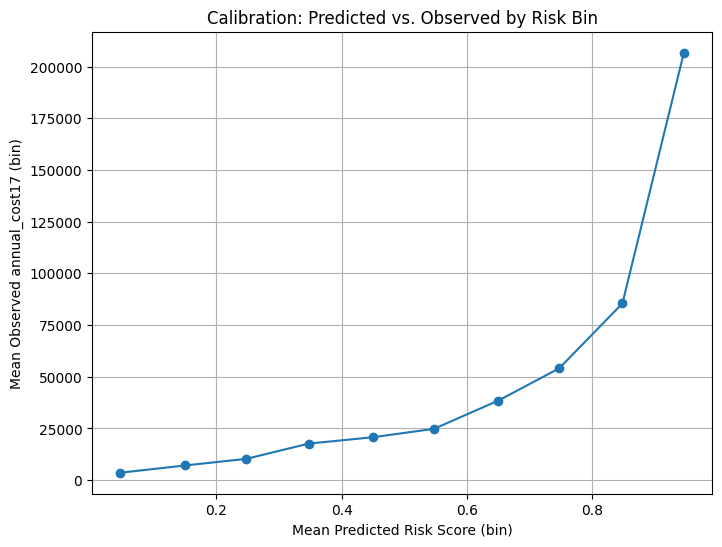

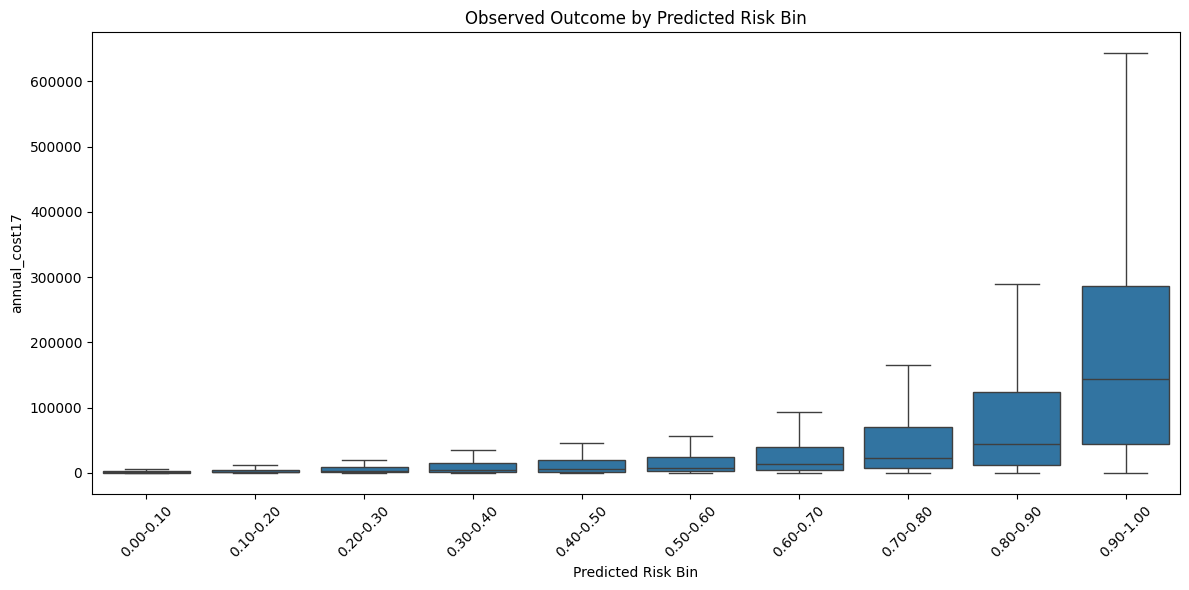

In [11]:
import matplotlib.pyplot as plt

# Calculate mean predicted and mean observed per bin
bin_means = df_binned.groupby("risk_bin").agg(
    mean_predicted=("risk_score", "mean"),
    mean_observed=(stratifier_target_column, "mean"),
    count=("risk_score", "count")
).reset_index()

plt.figure(figsize=(8, 6))
plt.plot(bin_means["mean_predicted"], bin_means["mean_observed"], marker="o")
plt.xlabel("Mean Predicted Risk Score (bin)")
plt.ylabel(f"Mean Observed {stratifier_target_column} (bin)")
plt.title("Calibration: Predicted vs. Observed by Risk Bin")
plt.grid(True)
plt.show()
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(x="risk_bin", y=stratifier_target_column, data=df_binned, showfliers=False)
plt.xticks(rotation=45)
plt.xlabel("Predicted Risk Bin")
plt.ylabel(stratifier_target_column)
plt.title("Observed Outcome by Predicted Risk Bin")
plt.tight_layout()
plt.show()

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.metrics import mean_squared_log_error
# For FULL COHORT
y_true_full = df_og[stratifier_target_column]
y_pred_full = predictions

rmse_full = np.sqrt(mean_squared_error(y_true_full, y_pred_full))
mae_full = mean_absolute_error(y_true_full, y_pred_full)
r2_full = r2_score(y_true_full, y_pred_full)
msle_full = mean_squared_log_error(y_true_full, y_pred_full)


# For TRAINING SUBGROUP
y_true_train = stratifier_train_pd[stratifier_target_column]
y_pred_train = training_predictions

rmse_train = np.sqrt(mean_squared_error(y_true_train, y_pred_train))
mae_train = mean_absolute_error(y_true_train, y_pred_train)
r2_train = r2_score(y_true_train, y_pred_train)
msle_train = mean_squared_log_error(y_true_train, y_pred_train)


print(f"Stratifier performance:")
print(f"  RMSE: {rmse_full:.2f} (full data), {rmse_train:.2f} (train)")
print(f"  Mean squared log error: {msle_full:.2f} (full), {msle_train:.2f}(train)")
print(f"  R²: {r2_full:.3f} (full),{r2_train:.3f} (train)")


Stratifier performance:
  RMSE: 62698.27 (full data), 69352.07 (train)
  Mean squared log error: 7.55 (full), 5.00(train)
  R²: 0.328 (full),0.698 (train)


In [17]:
train_df = df_binned[df_binned["ENROLID"].isin(train_ids)].reset_index(drop=True)
test_df  = df_binned[df_binned["ENROLID"].isin(test_ids)].reset_index(drop=True)
X_train, y_train = train_df[feature_cols], train_df["high_cost_2018"]
X_test,y_test = test_df[feature_cols], test_df['high_cost_2018']

In [44]:
train_df.to_csv("train_df_regression_0827.csv",index=False)
test_df.to_csv("test_df_regression_0827.csv",index=False)

In [31]:

# Logistic Regression for binary high-cost prediction
print("Training Logistic Regression model...")
log_pipeline = model_pipeline.get_logistic_pipeline(
    df=X_train,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, C=0.1, max_iter=1000,
)
log_pipeline.fit(X_train, y_train)  # Binary classification

# Random Forest for binary high-cost prediction
print("Training Random Forest model...")
rf_pipeline = model_pipeline.get_random_forest_pipeline(
    df=X_train ,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, 
)
rf_pipeline.fit(X_train, y_train )  # Binary classification

# Gradient Boosting for binary high-cost prediction
print("Training Gradient Boosting model...")
gb_pipeline = model_pipeline.get_histgb_pipeline(
   df=X_train ,categorical_cols=CAT_COLUMNS, numeric_cols=TRUE_NUM_COLUMNS, balance_classes = True
)
gb_pipeline.fit(X_train, y_train)  # Binary classification

# ===== Evaluate models using standard metrics =====
print("\nStandard evaluation metrics:")

print("\nLogistic Regression:")
model_pipeline.evaluate_model_auc(log_pipeline, X_test, y_test, highcost_cutoff=highcost_cutoff, optimal_threshold=True)

print("\nRandom Forest:")
model_pipeline.evaluate_model_auc(rf_pipeline, X_test, y_test, highcost_cutoff=highcost_cutoff, optimal_threshold=True)

print("\nGradient Boosting:")
model_pipeline.evaluate_model_auc(gb_pipeline, X_test, y_test, highcost_cutoff=highcost_cutoff, optimal_threshold=False)



Training Logistic Regression model...
→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY']
   • StandardScaler on: ['cost_stratum_2017', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1_procedure_ckd_cost', '2017Q1_comorbidity_ckd_cost', '2017Q2_ckd_cost', '2017Q2_ckd_claims', '2017Q2_direct_ckd_cost', '2017Q2_procedure_ckd_cost', '2017Q2_comorbidity_ckd_cost', '2017Q3_ckd_cost', '2017Q3_ckd_claims', '2017Q3_direct_ckd_cost', '2017Q3_procedure_ckd_cost', '2017Q3_comorbidity_ckd_cost', '2017Q4_ckd_cost', '2017Q4_ckd_claims', '2017Q4_direct_ckd_cost', '2017Q4_procedure_ckd_cost', '2017Q4_comorbidity_ckd_cost', 'total_ckd_cost_2017', 'ckd_cost_trend_2017', 'ckd_cost_volatility_2017', 'util_2017']
Training Random Forest model...
→ Building preprocessor:
   • OneHotEncoder on: ['AGEGRP', 'SEX', 'REGION', 'INDSTRY']
   • StandardScaler on: ['cost_stratum_2017', '2017Q1_ckd_cost', '2017Q1_ckd_claims', '2017Q1_direct_ckd_cost', '2017Q1

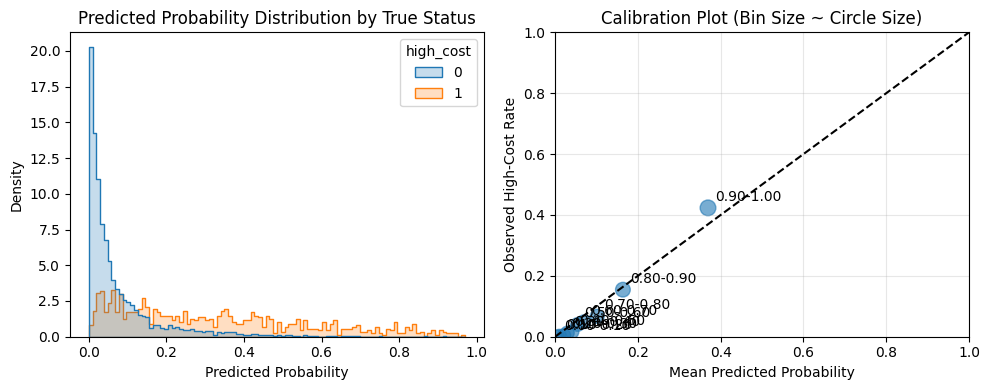

In [32]:
plot_probability_and_calibration(rf_pipeline, X_test, y_test, test_df['risk_bin'])

In [41]:
# Example: Pass status to the evaluation function
log_results_before = evaluate_metrics_by_risk_bin(
    log_pipeline, X_test, y_test, test_df['risk_bin'],
    model_name='Logistic Regression',
    dataset_name='Before Matching'
)# Random Forest results BEFORE matching
rf_results_before = evaluate_metrics_by_risk_bin(
    rf_pipeline, X_test, y_test, test_df['risk_bin'],
    model_name='Random Forest',
    dataset_name='Before Matching'
)
# Gradient Boosting results BEFORE matching
gb_results_before = evaluate_metrics_by_risk_bin(
    gb_pipeline, X_test, y_test, test_df['risk_bin'],
    model_name='Balanced XGBoost',
    dataset_name='Before Matching'
)



0.00-0.10
Risk bin 0.00-0.10 contains only one class, skipping confusion matrix
0.10-0.20
0.20-0.30
0.30-0.40
0.40-0.50
0.50-0.60
0.60-0.70
0.70-0.80
0.80-0.90
0.90-1.00
0.00-0.10
Risk bin 0.00-0.10 contains only one class, skipping confusion matrix
0.10-0.20
0.20-0.30
0.30-0.40
0.40-0.50
0.50-0.60
0.60-0.70
0.70-0.80
0.80-0.90
0.90-1.00
0.00-0.10
Risk bin 0.00-0.10 contains only one class, skipping confusion matrix
0.10-0.20
0.20-0.30
0.30-0.40
0.40-0.50
0.50-0.60
0.60-0.70
0.70-0.80
0.80-0.90
0.90-1.00


In [1]:
# Concatenate all results
all_results = pd.concat([log_results_before, rf_results_before, gb_results_before], ignore_index=True)

# Compare models
evaluate_model_by_risk_bin.plot_model_comparison_by_risk_bin(all_results,metric = "recall")


NameError: name 'pd' is not defined

### Feature Importance


Analyzing Logistic Regression feature importance...


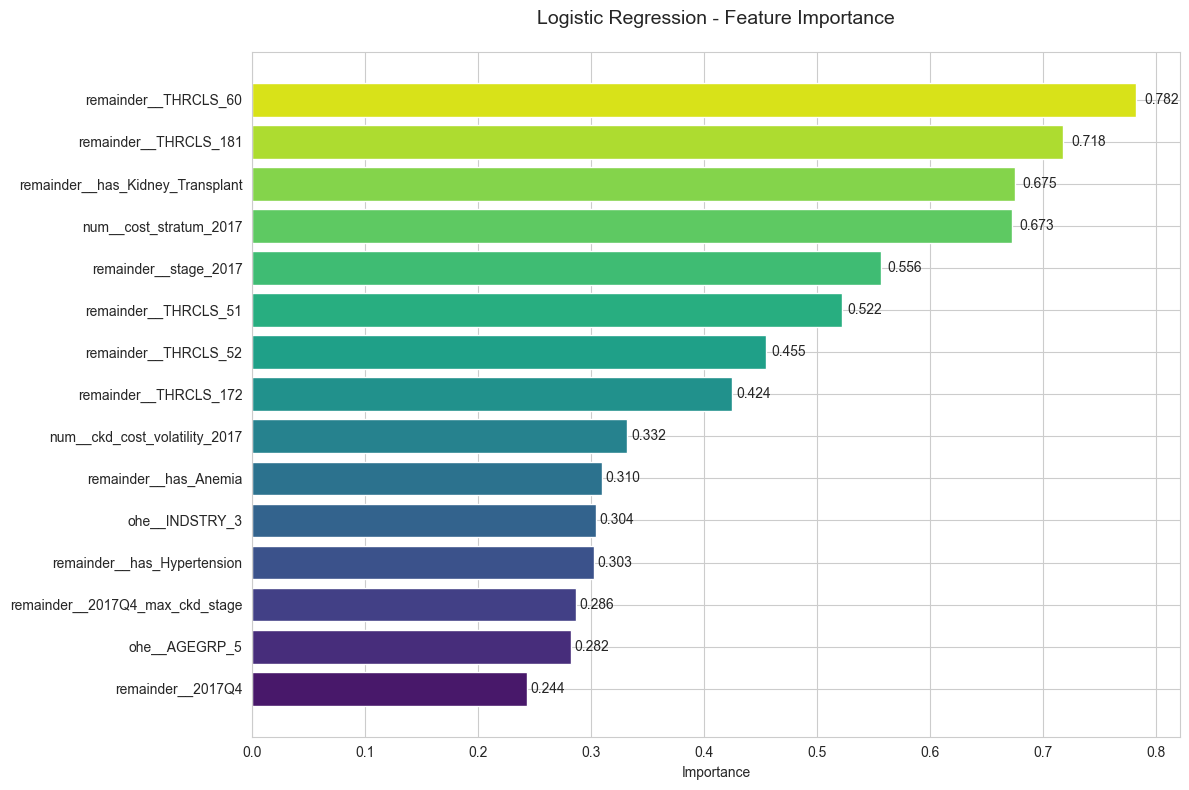

Top 10 features from Logistic Regression:
                feature  importance
0  remainder__THRCLS_60    0.782078

Analyzing Random Forest feature importance...


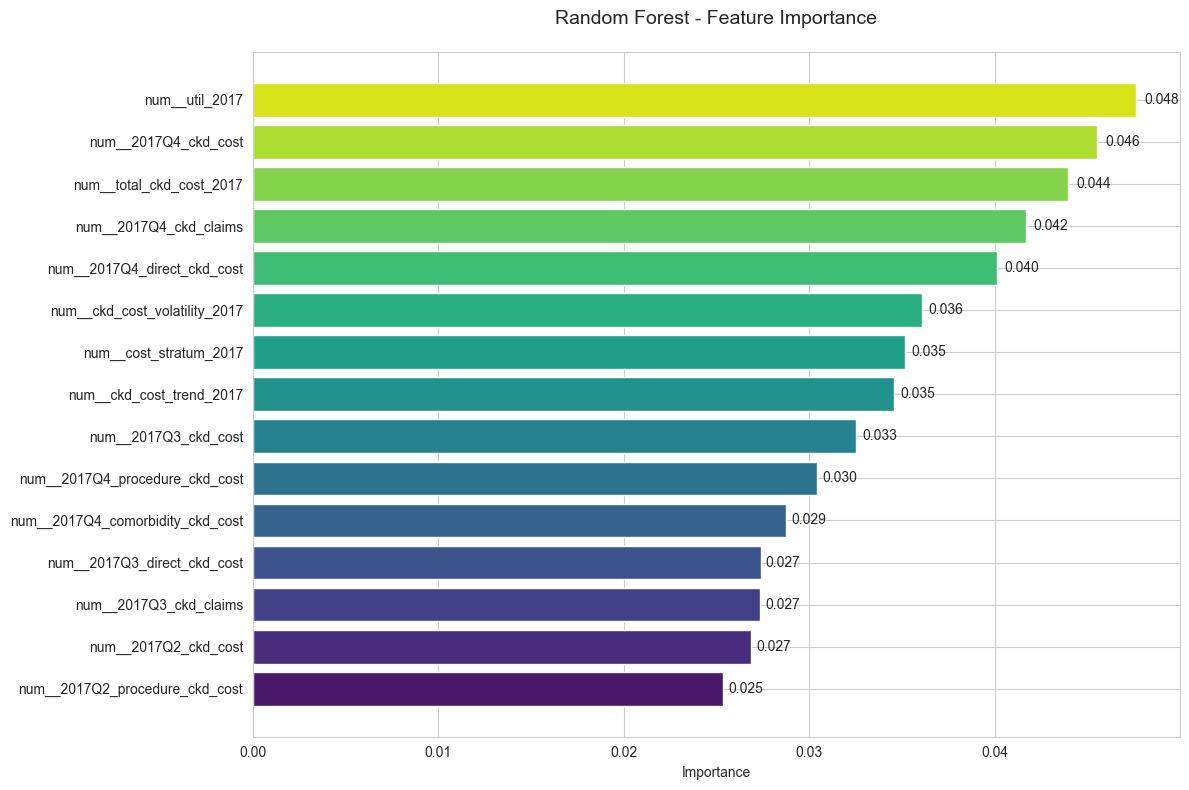

Top 10 features from Random Forest:
          feature  importance
0  num__util_2017    0.047612


In [78]:
import feature_importance
importlib.reload(feature_importance)
importlib.reload(model_pipeline)

# Logistic Regression feature importance
print("\nAnalyzing Logistic Regression feature importance...")
log_fig, log_importance = feature_importance.analyze_feature_importance(
    log_pipeline, X_train, y_train, X_test, y_test,
    method='built_in', top_n=15, 
    title="Logistic Regression - Feature Importance",
    return_df=True
)
plt.show()
print("Top 10 features from Logistic Regression:")
print(log_importance.head(1))

# Random Forest feature importance
print("\nAnalyzing Random Forest feature importance...")
rf_fig, rf_importance = feature_importance.analyze_feature_importance(
    rf_pipeline, X_train, y_train, X_test, y_test,
    method='built_in', top_n=15, 
    title="Random Forest - Feature Importance",
    return_df=True
)
plt.show()
print("Top 10 features from Random Forest:")
print(rf_importance.head(1))


In [ ]:
# Gradient Boosting feature importance
print("\nAnalyzing Gradient Boosting feature importance...")
gb_fig, gb_importance = feature_importance.analyze_feature_importance(
    gb_pipeline, X_train, y_train, X_test, y_test,
    method='permutation', top_n=15, 
    title="Gradient Boosting - Feature Importance",
)
plt.show()
print("Top 10 features from Gradient Boosting:")
print(gb_importance.head(10))
